Mounted at /content/drive
(85, 2)
41
44
77.40437695606688
78.38912509442049
Index(['year', 'mean_temp_max_f'], dtype='object')


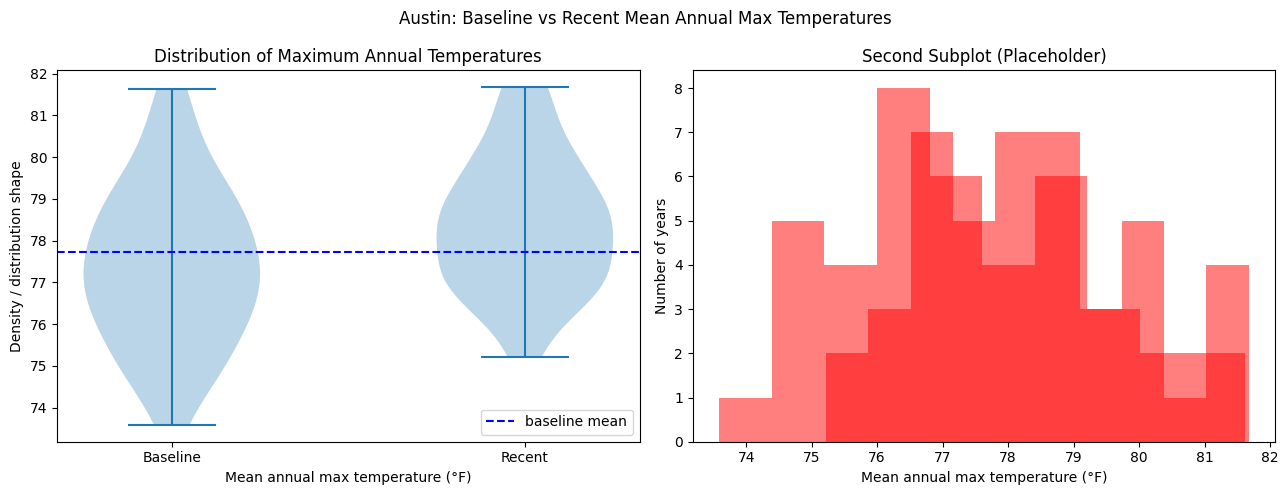

U statistic: 1179.00
P-value: 7.5131e-03
Effect size r: -0.307
T-statistic: 2.567
p-value: 6.0787e-03
=== HYPOTHESIS TEST SUMMARY FOR Austin ===
Baseline: 1940 to 1980 (41 years)
Recent: 1981 to 2024 (44 years)
Mean difference: 0.9847
Mann-Whitney U: 1179.00, p = 7.5131e-03
Effect size r: -0.307
Welch t: 2.567, p = 6.0787e-03
Decision (alpha=0.05): Reject H0
Hypothesis test summary saved to hypothesis_test_summary_austin.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

baseline_mean = 77.7160
baseline_std = 1.8677
cutoff_year = 1980

annual = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')

print(annual.shape)

baseline = annual[annual['year'] <= cutoff_year]
recent = annual[annual['year'] > cutoff_year]
print(len(baseline))
print(len(recent))
print(baseline['mean_temp_max_f'].mean())
print(recent['mean_temp_max_f'].mean())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.violinplot([baseline['mean_temp_max_f'], recent['mean_temp_max_f']], positions=[1, 2])
ax1.set_xticks([1, 2], ['Baseline (<=1980)', 'Recent (>1980)'])
ax1.set_ylabel('Maximum Temperature (F)')
ax1.set_title('Distribution of Maximum Annual Temperatures')

ax2.set_xlabel('X-axis for ax2')
ax2.set_ylabel('Y-axis for ax2')
ax2.set_title('Second Subplot (Placeholder)')
print(annual.columns)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Baseline', 'Recent'])
ax1.axhline(baseline_mean, linestyle='dashed', color='blue', label='baseline mean')
ax1.legend()
ax2.hist(baseline['mean_temp_max_f'], alpha=0.5, color='red', label='Baseline')
ax2.hist(recent['mean_temp_max_f'], alpha=0.5, color='red', label='Recent')
ax1.set_xlabel('Mean annual max temperature (°F)')
ax1.set_ylabel('Density / distribution shape')
ax2.set_xlabel('Mean annual max temperature (°F)')
ax2.set_ylabel('Number of years')
plt.suptitle('Austin: Baseline vs Recent Mean Annual Max Temperatures')
plt.tight_layout()
plt.show()
baseline_temps = baseline['mean_temp_max_f'].dropna()
recent_temps = recent['mean_temp_max_f'].dropna()
U, p = stats.mannwhitneyu(recent_temps, baseline_temps, alternative='greater')
print(f'U statistic: {U:.2f}')
print(f'P-value: {p:.4e}')
n1 = len(baseline_temps)
n2 = len(recent_temps)
r = 1 - 2*U/(n1*n2)
n1 = 44
n2 = 41
print(f'Effect size r: {r:.3f}')
t_stat, p_t = stats.ttest_ind(recent_temps, baseline_temps, equal_var=False, alternative='greater')
print(f'T-statistic: {t_stat:.3f}')
print(f'p-value: {p_t:.4e}')

print('=== HYPOTHESIS TEST SUMMARY FOR Austin ===')
print(f'Baseline: {baseline["year"].min()} to {baseline["year"].max()} ({len(baseline)} years)')
print(f'Recent: {recent["year"].min()} to {recent["year"].max()} ({len(recent)} years)')
print(f'Mean difference: {recent_temps.mean() - baseline_temps.mean():.4f}')
print(f'Mann-Whitney U: {U:.2f}, p = {p:.4e}')
print(f'Effect size r: {r:.3f}')
print(f'Welch t: {t_stat:.3f}, p = {p_t:.4e}')
decision = 'Reject H0' if p < 0.05 else 'Fail to reject H0'
print(f'Decision (alpha=0.05): {decision}')

summary_data = {
    'Metric': [
        'Baseline Years',
        'Baseline Count',
        'Recent Years',
        'Recent Count',
        'Mean Difference',
        'Mann-Whitney U',
        'Mann-Whitney p-value',
        'Effect Size r',
        'Welch t',
        'Welch p-value',
        'Decision (alpha=0.05)'
    ],
    'Value': [
        f'{baseline["year"].min()} to {baseline["year"].max()}',
        len(baseline),
        f'{recent["year"].min()} to {recent["year"].max()}',
        len(recent),
        f'{recent_temps.mean() - baseline_temps.mean():.4f}',
        f'{U:.2f}',
        f'{p:.4e}',
        f'{r:.3f}',
        f'{t_stat:.3f}',
        f'{p_t:.4e}',
        decision
    ]
}

summary_df = pd.DataFrame(summary_data)
output_filename = 'hypothesis_test_summary_austin.csv'
summary_df.to_csv(output_filename, index=False)
print(f'Hypothesis test summary saved to {output_filename}')

The `hypothesis_test_summary_austin.json` file has been created and saved.

I see that the violin plot is higher and the histogram is overlapping almost completely

I used the one right after the baseline to make sure there is no difference between the years.

- U statistic = 1179.00
- p-value = 0.0075131
- decision: Reject H0

- t = 2.567
- p = 0.0060787

=== HYPOTHESIS TEST SUMMARY FOR Austin ===
Baseline: 1940 to 1980 (41 years)
Recent: 1981 to 2024 (44 years)
Mean difference: 0.9847
Mann-Whitney U: 1179.00, p = 7.5131e-03
Effect size r: -0.307
Welch t: 2.567, p = 6.0787e-03
Decision (alpha=0.05): Reject H0